In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import numpy as np

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!cp -r "/content/drive/MyDrive/DDSM/ROI-data" "/content/ROI-data"

In [ ]:

data_dir = "/content/ROI-data"
img_size = (224, 224)
batch_size = 16
seed = 123
AUTOTUNE = tf.data.AUTOTUNE

# 1) Dataset split: train / val / test
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("class_name:", class_names)

temp_card = tf.data.experimental.cardinality(temp_ds).numpy()
val_batches = temp_card // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

def prepare(ds, shuffle=False, cache_path=None):
    if shuffle:
        ds = ds.shuffle(1000, seed=seed, reshuffle_each_iteration=True)
    if cache_path:
        ds = ds.cache(cache_path)
    return ds.prefetch(AUTOTUNE)
train_ds_prep = prepare(train_ds, shuffle=True, cache_path="/tmp/train_cache")
val_ds_prep   = prepare(val_ds, cache_path="/tmp/val_cache")
test_ds_prep  = prepare(test_ds, cache_path="/tmp/test_cache")

print("train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("val   batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("test  batches:", tf.data.experimental.cardinality(test_ds).numpy())



# 2) Model: augmentation + ResNet50 + classification head (with regularization)

data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.10),
        keras.layers.RandomZoom(0.20),
        keras.layers.RandomTranslation(0.05, 0.05),
        keras.layers.RandomContrast(0.20),
    ],
    name="data_augmentation"
)

base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=img_size + (3,)
)

inputs = keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)  # Active only during training
x = keras.applications.resnet50.preprocess_input(x)

# Keep BN in inference mode during the frozen stage for stability
x = base_model(x, training=False)

x = keras.layers.GlobalAveragePooling2D()(x)

# Use a larger dropout rate: 0.5
x = keras.layers.Dropout(0.5)(x)

# Typical choice: 1e-4; 3e-4 or 1e-3 can also be tried
l2 = tf.keras.regularizers.l2(1e-4)
outputs = keras.layers.Dense(
    1, activation="sigmoid",
    kernel_regularizer=l2,  # Apply L2 regularization to Dense weights
    bias_regularizer=None
)(x)

model = keras.Model(inputs, outputs)



# 3) Stage 1: freeze the backbone and train only the head

# Add label smoothing to reduce overconfidence and often stabilize val_auc
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)

callbacks_stage1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=3, restore_best_weights=True
    )
]

initial_epochs = 8
base_model.trainable = False
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,  # Use label smoothing with factor 0.05
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history1 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=initial_epochs,
    callbacks=callbacks_stage1
)

# 4) Stage 2: unfreeze only conv5_* and keep all BN layers frozen for small-batch stability
base_model.trainable = False

for layer in base_model.layers:
    if layer.name.startswith("conv5_"):
        layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total base_model layers:", len(base_model.layers))
print("Trainable layers:", sum(int(l.trainable) for l in base_model.layers))

best_path = "/mnt/e/SW_training_outputs/checkpoints/best_by_val_auc.keras"

# Reduce the learning rate automatically when val_auc plateaus
callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,     # learning rate * 0.5
        patience=2,     # reduce after 2 epochs without improvement
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,     # slightly relaxed patience to work with LR scheduling
        restore_best_weights=False,  # rely on the checkpoint file instead
        verbose=1
    ),
]

# Use AdamW for decoupled weight decay
try:
    opt2 = keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-5)
except Exception:
    opt2 = keras.optimizers.Adam(learning_rate=1e-5)

fine_tune_epochs = 50
total_epochs = initial_epochs + fine_tune_epochs

model.compile(
    optimizer=opt2,  # Prefer AdamW
    loss=loss_fn,   # Includes label smoothing
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history2 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=total_epochs,
    initial_epoch=initial_epochs,
    callbacks=callbacks_stage2
)


# 5) Evaluate the best saved model on the test set
best_model = tf.keras.models.load_model(best_path)
test_metrics = best_model.evaluate(test_ds_prep, verbose=1)
print("Best model test metrics:", dict(zip(best_model.metrics_names, test_metrics)))


Found 2830 files belonging to 2 classes.
Using 2264 files for training.
Found 2830 files belonging to 2 classes.
Using 566 files for validation.
class_name: ['Benign', 'Cancer']
train batches: 142
val   batches: 18
test  batches: 18
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
142/142 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step - accuracy: 0.4729 - auc: 0.4673 - loss: 0.9475 - val_accuracy: 0.5243 - val_auc: 0.5680 - val_loss: 0.7416
Epoch 2/8
142/142 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.4920 - auc: 0.4873 - loss: 0.8927 - val_accuracy: 0.5972 - val_auc: 0.6380 - val_loss: 0.7011
Epoch 3/8
142/142 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.4983 - auc: 0.5065 - loss: 0.8521 - val_accuracy: 0.6007 - val_auc: 0.6703 - val_loss: 0.6709
Epoch 4/8
142/142 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.5504 - auc: 0.5719 - loss: 0.7794 - val_accuracy: 0.6215 - val_auc: 0.6902 - val_loss: 0.6554
Epoch 5/8
142/142 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.5607

In [ ]:
print(best_model.metrics_names)
print(test_metrics)

['loss', 'compile_metrics']
[0.5922994017601013, 0.6726618409156799, 0.7582659721374512]


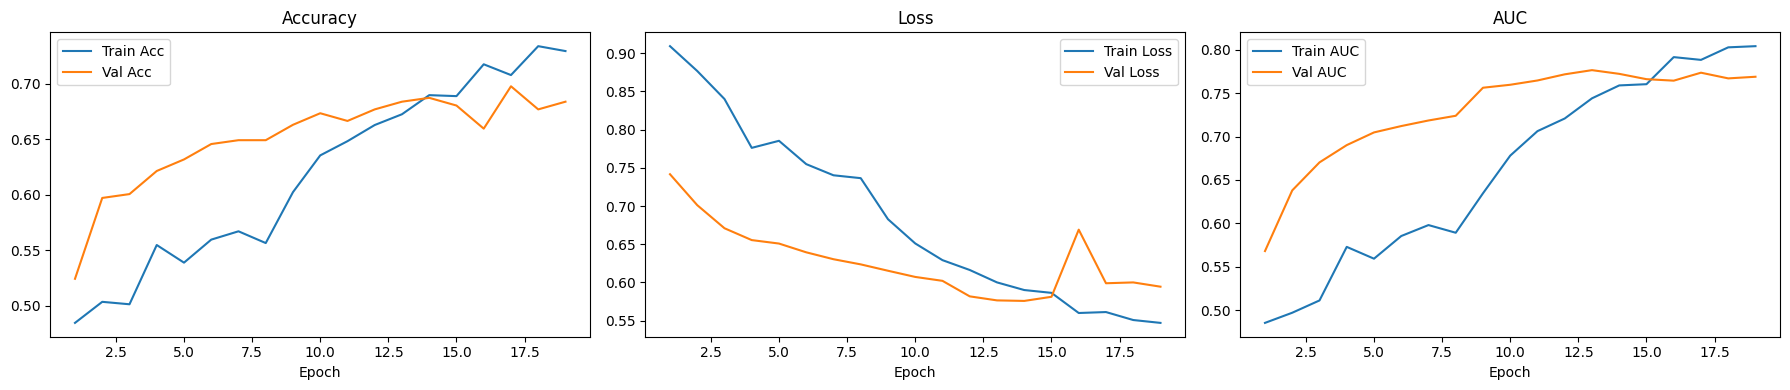

In [ ]:
import matplotlib.pyplot as plt

def plot_history(hist1, hist2=None):

    acc = hist1.history.get("accuracy", []).copy()
    val_acc = hist1.history.get("val_accuracy", []).copy()
    loss = hist1.history.get("loss", []).copy()
    val_loss = hist1.history.get("val_loss", []).copy()
    auc = hist1.history.get("auc", []).copy()
    val_auc = hist1.history.get("val_auc", []).copy()

    if hist2 is not None:
        acc += hist2.history.get("accuracy", [])
        val_acc += hist2.history.get("val_accuracy", [])
        loss += hist2.history.get("loss", [])
        val_loss += hist2.history.get("val_loss", [])
        auc += hist2.history.get("auc", [])
        val_auc += hist2.history.get("val_auc", [])

    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(18, 4))

    # Accuracy
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, acc, label="Train Acc")
    plt.plot(epochs_range, val_acc, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.xlabel("Epoch")

    # Loss
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.legend()
    plt.title("Loss")
    plt.xlabel("Epoch")

    # AUC
    plt.subplot(1, 3, 3)
    if len(auc) > 0 and len(val_auc) > 0:
        plt.plot(epochs_range, auc, label="Train AUC")
        plt.plot(epochs_range, val_auc, label="Val AUC")
        plt.legend()
        plt.title("AUC")
        plt.xlabel("Epoch")
    else:
        plt.title("AUC (not recorded)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_history(history1, history2)